# Laboratorio 1 — Series de Tiempo
## Bloque 3 — Análisis preliminar de 2 series

Análisis preliminar de las series **Total mensual** y **Vía Aérea** sobre el
conjunto de **entrenamiento** (2009-01 a 2021-03, 147 meses). Para cada serie se
cubren seis pasos: ficha, gráfico y lectura, descomposición, transformación de
varianza, estacionariedad en media (ACF/PACF, ADF y diferenciación) y, al
cierre, la comparación del comportamiento pandémico entre ambas.

No se ajusta ningún modelo (ARIMA/SARIMA, Prophet, Holt-Winters, etc.): eso
corresponde a la entrega final. Aquí solo se **diagnostica** la serie y se leen
los órdenes p, q, d y D que sugieren la ACF/PACF.

Solo se usa `pandas`, `matplotlib`, `statsmodels` y `scipy` (sin seaborn),
según la convención del equipo. Las figuras se guardan en `informe/figuras/`
con prefijo `serie_` a 150 dpi.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

RUTA_SERIES = "../data/processed/series"
RUTA_FIGURAS = "../informe/figuras"
os.makedirs(RUTA_FIGURAS, exist_ok=True)


def cargar_serie(nombre):
    s = pd.read_csv(os.path.join(RUTA_SERIES, nombre), parse_dates=["fecha"])
    s = s.set_index("fecha")["viajeros"]
    s.index.freq = "MS"
    return s


def reporte_adf(serie, etiqueta):
    r = adfuller(serie.dropna(), autolag="AIC")
    print(f"ADF [{etiqueta}]  estadístico={r[0]:.4f}  p-valor={r[1]:.4f}  "
          f"lags={r[2]}  n={r[3]}")
    print(f"  valores críticos: 1%={r[4]['1%']:.3f}  "
          f"5%={r[4]['5%']:.3f}  10%={r[4]['10%']:.3f}")
    return r


total = cargar_serie("serie_total_train.csv")
aerea = cargar_serie("serie_via_aerea_train.csv")
print("total:", total.index.min().date(), "->", total.index.max().date(), len(total))
print("aerea:", aerea.index.min().date(), "->", aerea.index.max().date(), len(aerea))

total: 2009-01-01 -> 2021-03-01 147
aerea: 2009-01-01 -> 2021-03-01 147


In [2]:
def analizar_serie(clave, serie, color):
    """Ejecuta los pasos 1-5 para una serie y guarda las figuras serie_<clave>_*.png."""
    # Paso 1 — Ficha
    print(f"===== {clave.upper()} =====")
    print(f"Inicio: {serie.index.min():%Y-%m}   Fin: {serie.index.max():%Y-%m}   "
          f"Frecuencia: mensual (12/año)   Observaciones: {len(serie)}")
    print(f"Mín: {serie.min():,.0f} ({serie.idxmin():%Y-%m})   "
          f"Máx: {serie.max():,.0f} ({serie.idxmax():%Y-%m})")
    print(f"Media: {serie.mean():,.0f}   Mediana: {serie.median():,.0f}")

    # Paso 2 — Gráfico en niveles
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(serie.index, serie.values, color=color)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
               color="tab:red", alpha=0.12)
    ax.set_title(f"Serie mensual — {clave} (entrenamiento 2009-01 a 2021-03)")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Viajeros")
    fig.tight_layout()
    fig.savefig(os.path.join(RUTA_FIGURAS, f"serie_{clave}_nivel.png"), dpi=150)
    plt.show()

    # amplitud vs nivel (justifica descomposición multiplicativa)
    pre, mid = serie.loc["2009":"2013"], serie.loc["2014":"2019"]
    print(f"Amplitud vs nivel — std 2009-2013={pre.std():,.0f} (media {pre.mean():,.0f}) | "
          f"std 2014-2019={mid.std():,.0f} (media {mid.mean():,.0f})")

    # Paso 3 — Descomposición multiplicativa
    desc = seasonal_decompose(serie, model="multiplicative", period=12,
                              extrapolate_trend="freq")
    fig = desc.plot(); fig.set_size_inches(11, 8)
    fig.suptitle(f"Descomposición multiplicativa — {clave}", y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(RUTA_FIGURAS, f"serie_{clave}_descomposicion.png"), dpi=150)
    plt.show()
    # índice estacional honesto sobre el tramo estable pre-pandemia
    prep = serie.loc["2009":"2019"]
    idx_est = prep.groupby(prep.index.month).mean() / prep.mean()
    print("Índice estacional pre-pandemia (mes: factor):")
    print({int(m): round(v, 2) for m, v in idx_est.sort_values(ascending=False).items()})

    # Paso 4 — Transformación de varianza (log1p; hay valores muy bajos)
    log_serie = np.log1p(serie)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(serie.index, serie.values, color=color); axes[0].set_title(f"{clave} — original")
    axes[1].plot(log_serie.index, log_serie.values, color=color); axes[1].set_title(f"{clave} — log1p")
    for a in axes: a.set_xlabel("Fecha")
    fig.tight_layout()
    fig.savefig(os.path.join(RUTA_FIGURAS, f"serie_{clave}_log.png"), dpi=150)
    plt.show()

    # Paso 5 — ACF/PACF en niveles (log) + ADF
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(log_serie, lags=36, ax=axes[0]); axes[0].set_title(f"ACF — log {clave} (niveles)")
    plot_pacf(log_serie, lags=36, ax=axes[1], method="ywm"); axes[1].set_title(f"PACF — log {clave} (niveles)")
    fig.tight_layout()
    fig.savefig(os.path.join(RUTA_FIGURAS, f"serie_{clave}_acf_niveles.png"), dpi=150)
    plt.show()

    reporte_adf(log_serie, "log niveles")
    reporte_adf(log_serie.diff().dropna(), "d=1")
    d1s12 = log_serie.diff().diff(12).dropna()
    reporte_adf(d1s12, "d=1 + D=1 (s=12)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(d1s12, lags=36, ax=axes[0]); axes[0].set_title(f"ACF — log {clave} diferenciada (d=1, D=1)")
    plot_pacf(d1s12, lags=36, ax=axes[1], method="ywm"); axes[1].set_title(f"PACF — log {clave} diferenciada (d=1, D=1)")
    fig.tight_layout()
    fig.savefig(os.path.join(RUTA_FIGURAS, f"serie_{clave}_acf_diff.png"), dpi=150)
    plt.show()
    return log_serie

---
## Serie 1 — Total mensual

Serie obligatoria: total de viajeros que ingresan a Guatemala por mes. Se ejecutan
los pasos 1 a 5 y luego se interpretan.

===== TOTAL =====
Inicio: 2009-01   Fin: 2021-03   Frecuencia: mensual (12/año)   Observaciones: 147
Mín: 9,779 (2020-05)   Máx: 515,820 (2019-12)
Media: 237,121   Mediana: 216,161


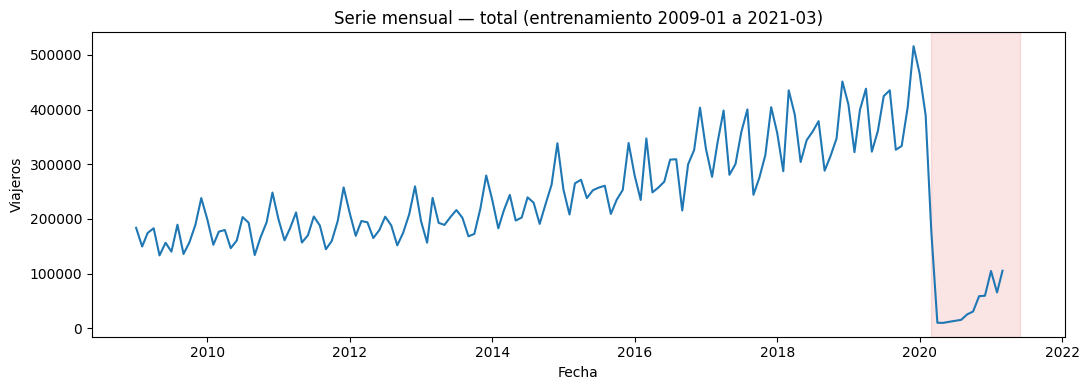

Amplitud vs nivel — std 2009-2013=31,782 (media 185,752) | std 2014-2019=74,036 (media 307,918)


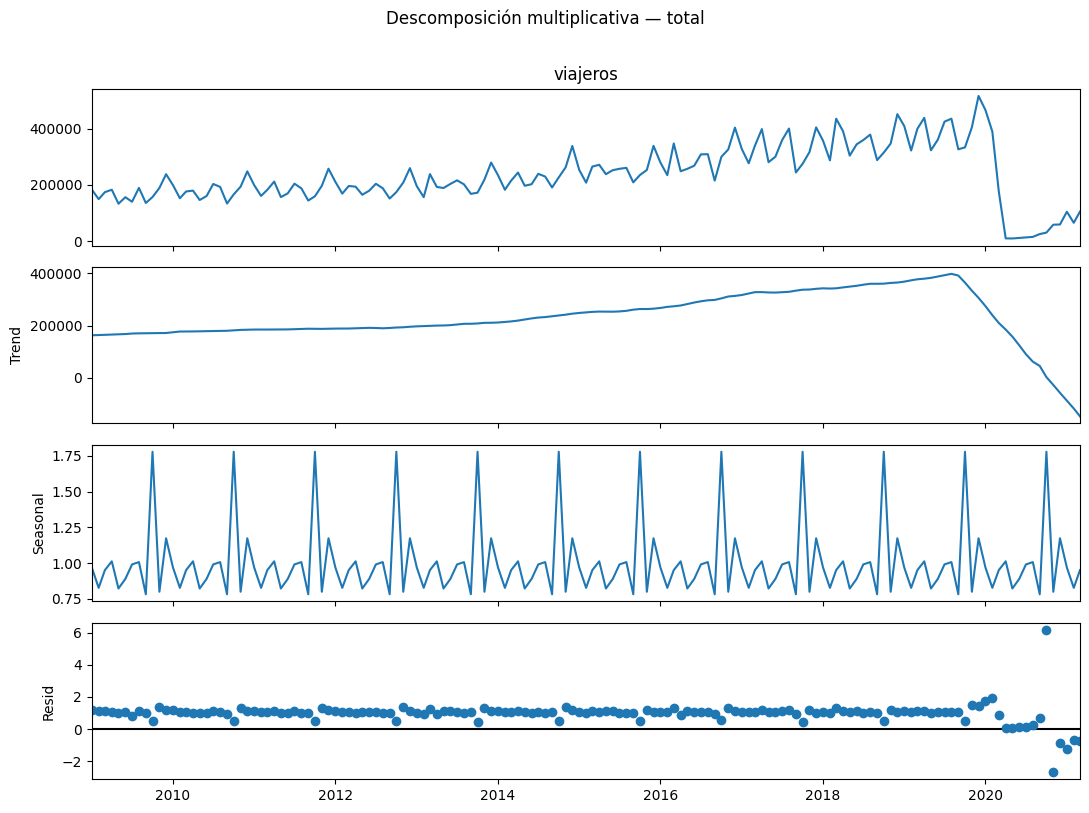

Índice estacional pre-pandemia (mes: factor):
{12: 1.35, 8: 1.07, 3: 1.07, 4: 1.06, 11: 1.05, 7: 1.05, 1: 1.03, 6: 0.94, 10: 0.91, 5: 0.86, 2: 0.83, 9: 0.8}


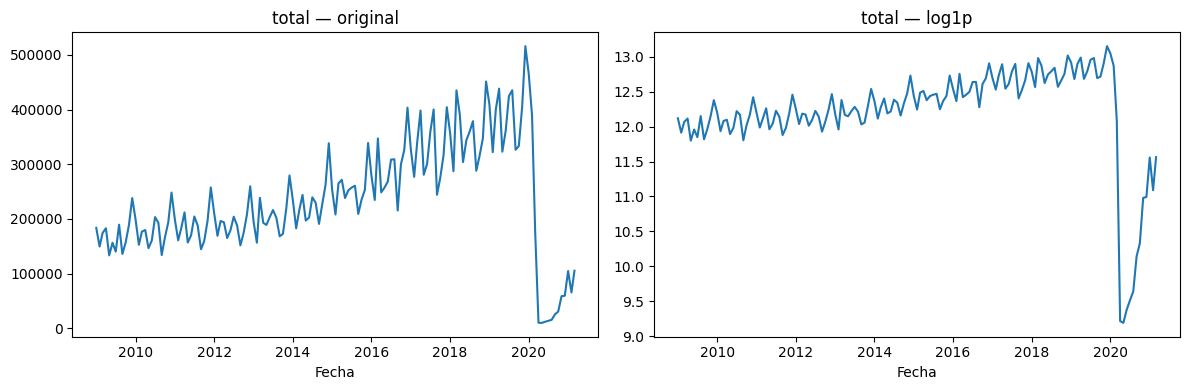

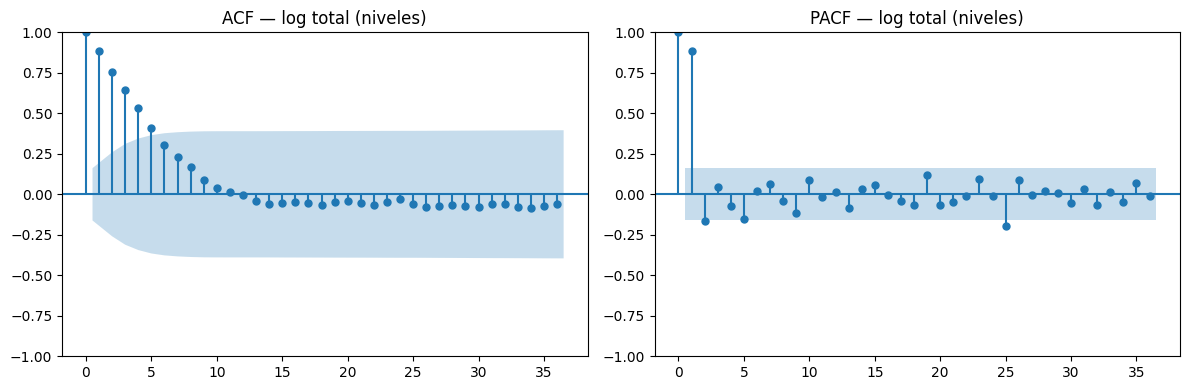

ADF [log niveles]  estadístico=-2.2356  p-valor=0.1936  lags=12  n=134
  valores críticos: 1%=-3.480  5%=-2.883  10%=-2.578
ADF [d=1]  estadístico=-3.1003  p-valor=0.0265  lags=11  n=134
  valores críticos: 1%=-3.480  5%=-2.883  10%=-2.578
ADF [d=1 + D=1 (s=12)]  estadístico=-6.1477  p-valor=0.0000  lags=11  n=122
  valores críticos: 1%=-3.485  5%=-2.886  10%=-2.580


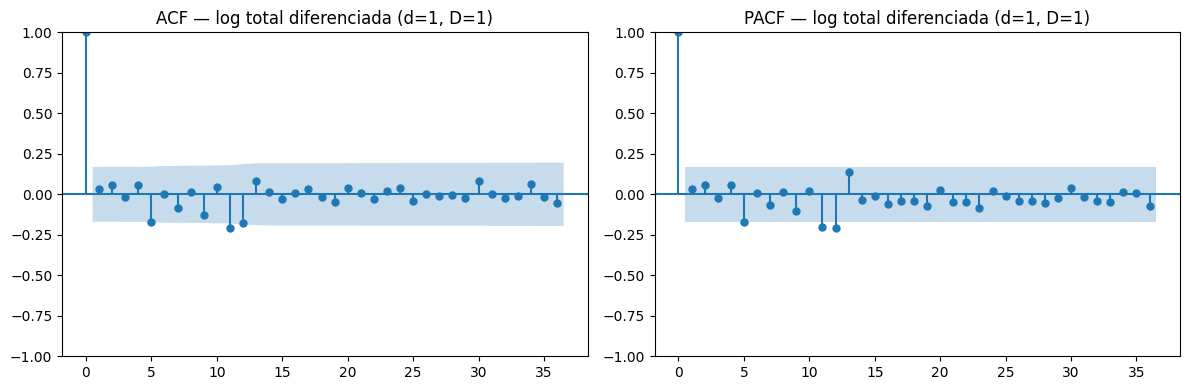

In [3]:
log_total = analizar_serie('total', total, 'tab:blue')

**Interpretación — Total mensual.**

1. **Ficha.** Enero 2009 a marzo 2021, mensual, 147 observaciones. Media ~237,000
   viajeros/mes; mínimo **9,779 en mayo 2020** (colapso pandémico) y máximo
   **515,820 en diciembre 2019** (pico prepandemia).
2. **Lectura del gráfico.** Nivel creciente (de ~169,000 en 2009 a ~391,000 en 2019),
   estacionalidad anual marcada y el quiebre abrupto de 2020. La amplitud de las
   oscilaciones **crece con el nivel** (la desviación pasa de ~32,000 en 2009-2013 a
   ~74,000 en 2014-2019): esto justifica una descomposición **multiplicativa** y una
   transformación estabilizadora de varianza.
3. **Descomposición.** Tendencia creciente hasta 2019 y desplome en 2020. Estacionalidad
   estable con **pico en diciembre** (factor ~1.35) y **valle en septiembre** (~0.80),
   con repunte secundario en Semana Santa (marzo). Para el INGUAT esto implica planificar
   capacidad para el fin de año y aprovechar el valle de septiembre para mantenimiento.
   El **residuo NO es ruido**: 2020 deja una estructura enorme sin explicar (los factores
   multiplicativos de ese año se distorsionan), por eso la lectura estacional se toma del
   tramo estable 2009-2019. No hay estacionariedad en media ni en varianza.
4. **Transformación.** Se aplica `log1p` (hay meses de valores muy bajos): estabiliza la
   varianza y vuelve aproximadamente aditiva la estacionalidad, condición útil para el
   modelado posterior.
5. **Estacionariedad en media.** La ACF en niveles decae lentamente y se mantiene alta en
   muchos rezagos → evidencia de no estacionariedad. **ADF en niveles: p=0.194**, no se
   rechaza la raíz unitaria (no estacionaria). Con **una diferencia regular (d=1)** el ADF
   baja a **p=0.027** (estacionaria al 5%) y añadiendo **diferencia estacional (D=1, s=12)**
   a **p<0.001**, con ACF/PACF mucho más limpias. Conclusión: **d=1, D=1**. La ACF de la
   serie diferenciada sugiere componentes MA de orden bajo (q≈1) y estacional (Q≈1), y la
   PACF, AR de orden bajo (p≈1, P≈1). Hasta aquí: no se ajusta ningún modelo.

---
## Serie 2 — Vía Aérea

Serie de contraste: es la que mejor complementa al total porque colapsó a casi cero en
2020 mientras la terrestre mantuvo flujo.

===== AEREA =====
Inicio: 2009-01   Fin: 2021-03   Frecuencia: mensual (12/año)   Observaciones: 147
Mín: 489 (2020-04)   Máx: 157,842 (2019-12)
Media: 89,141   Mediana: 89,750


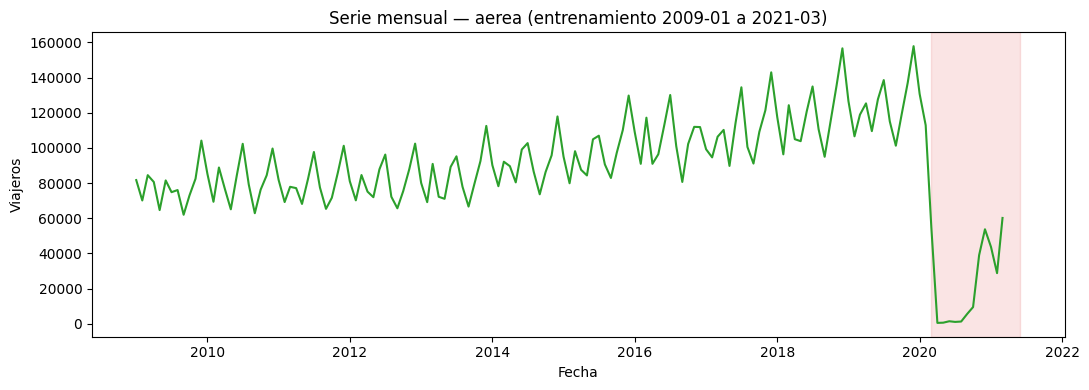

Amplitud vs nivel — std 2009-2013=11,554 (media 80,548) | std 2014-2019=18,464 (media 107,323)


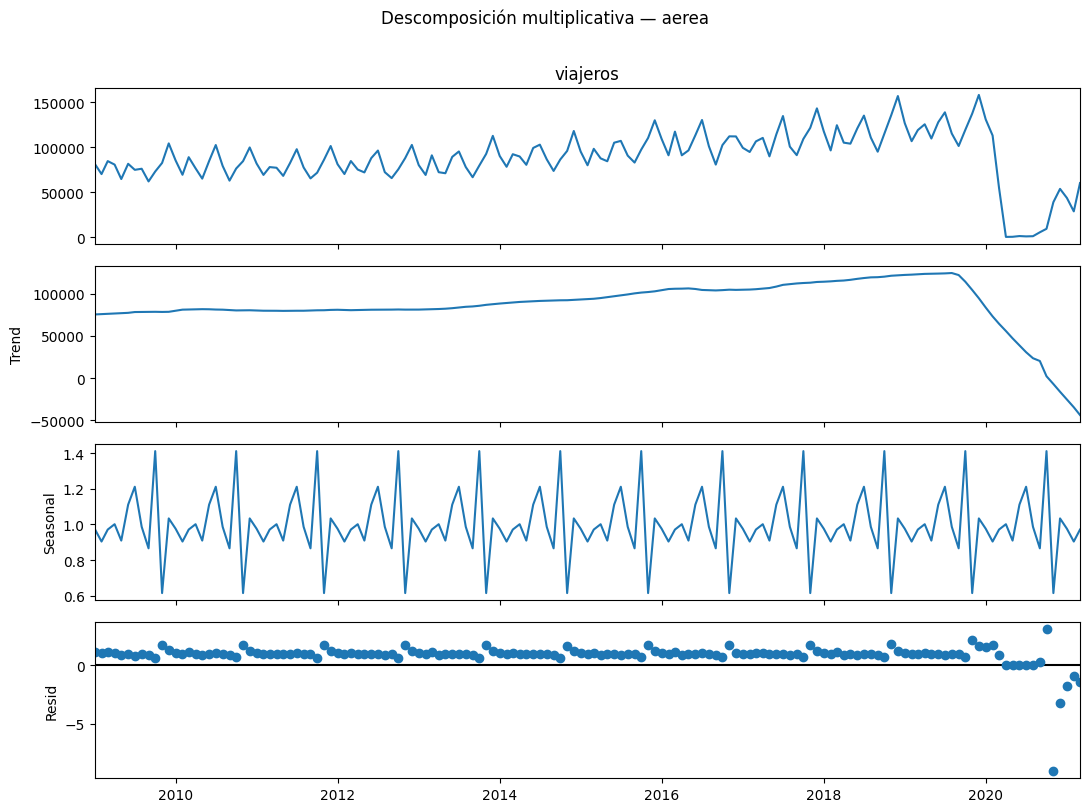

Índice estacional pre-pandemia (mes: factor):
{12: 1.28, 7: 1.16, 11: 1.09, 6: 1.06, 3: 1.04, 1: 1.0, 10: 0.96, 4: 0.95, 8: 0.94, 5: 0.86, 2: 0.85, 9: 0.81}


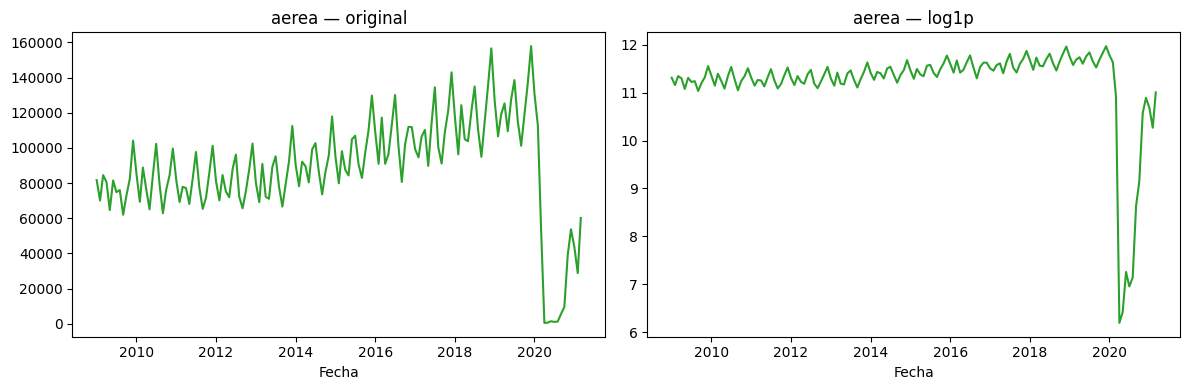

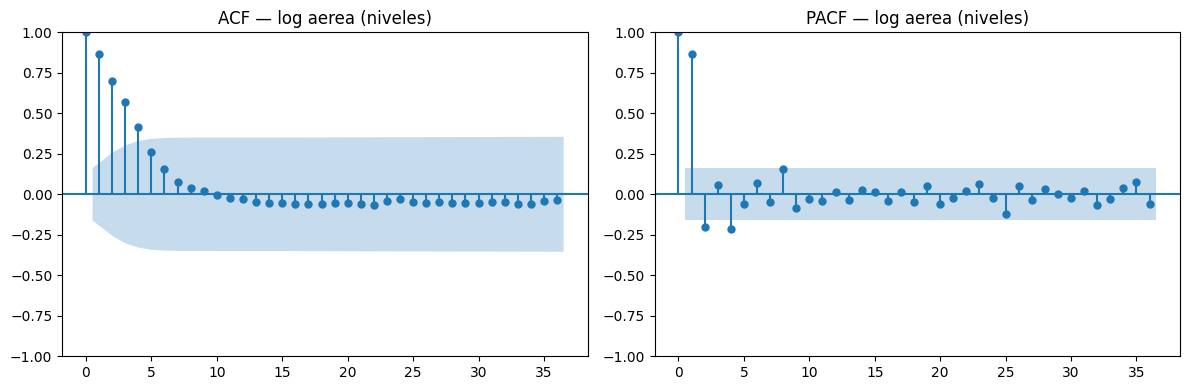

ADF [log niveles]  estadístico=-4.0179  p-valor=0.0013  lags=3  n=143
  valores críticos: 1%=-3.477  5%=-2.882  10%=-2.578
ADF [d=1]  estadístico=-3.2134  p-valor=0.0192  lags=11  n=134
  valores críticos: 1%=-3.480  5%=-2.883  10%=-2.578
ADF [d=1 + D=1 (s=12)]  estadístico=-6.3961  p-valor=0.0000  lags=11  n=122
  valores críticos: 1%=-3.485  5%=-2.886  10%=-2.580


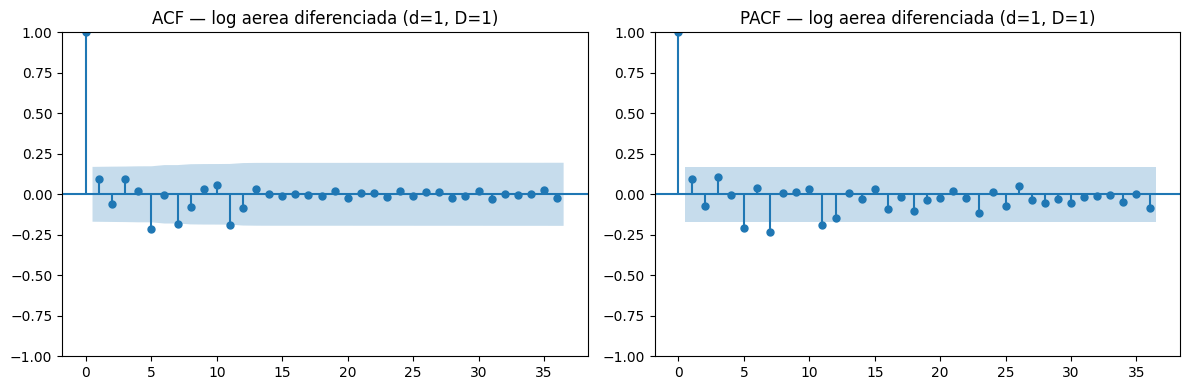

In [4]:
log_aerea = analizar_serie('aerea', aerea, 'tab:green')

**Interpretación — Vía Aérea.**

1. **Ficha.** Enero 2009 a marzo 2021, mensual, 147 observaciones. Media ~89,000
   viajeros/mes; mínimo **489 en abril 2020** (aeropuerto prácticamente cerrado) y máximo
   **157,842 en diciembre 2019**.
2. **Lectura del gráfico.** Tendencia creciente más suave que el total (de ~78,000 en 2009
   a ~124,000 en 2019) y **caída aún más profunda** en 2020. La amplitud también crece con
   el nivel (std ~12,000 → ~18,000), de nuevo a favor de descomposición multiplicativa y
   transformación.
3. **Descomposición.** Tendencia creciente hasta 2019; estacionalidad con **pico en
   diciembre** (~1.28) y **valle en septiembre** (~0.81), con repunte en julio (vacaciones
   del hemisferio norte, coherente con el mercado estadounidense). El residuo tampoco es
   ruido: 2020 domina la varianza. Ni media ni varianza son constantes.
4. **Transformación.** `log1p` (imprescindible aquí: el valor de abril 2020 es 489, muy
   cercano a cero) estabiliza la varianza.
5. **Estacionariedad en media.** Caso matizado: el **ADF en niveles da p=0.001**, que
   formalmente rechazaría la raíz unitaria; sin embargo la ACF decae lentamente y la
   tendencia y estacionalidad son evidentes, de modo que el ADF está siendo engañado por la
   fuerte reversión pandémica. El diagnóstico robusto (ACF + necesidad de estacionalidad)
   indica igualmente diferenciar: con **d=1** el ADF da p=0.019 y con **D=1 (s=12)**
   p<0.001, dejando ACF/PACF limpias. Conclusión práctica: **d=1, D=1**, con órdenes
   sugeridos p≈1, q≈1 y estacionales P≈1, Q≈1. No se ajusta ningún modelo.

---
## Paso 6 — Comportamiento durante y después de la pandemia

Comparación explícita de ambas series en el evento pandémico (lo pide la rúbrica del avance).

total   media 2019=  390,985  mínimo pandemia=   9,779 (2020-05)  caída= 97.5%
aerea   media 2019=  123,615  mínimo pandemia=     489 (2020-04)  caída= 99.6%


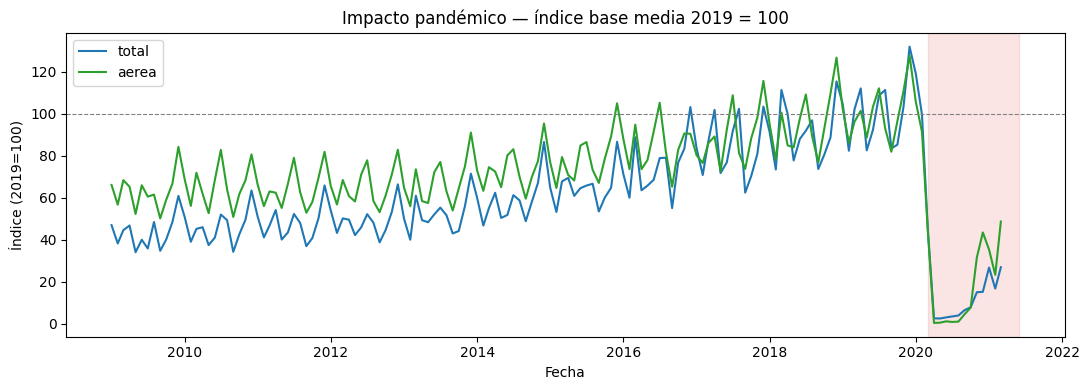

In [5]:
base_total = total.loc["2019"].mean()
base_aerea = aerea.loc["2019"].mean()
for clave, s, base in [("total", total, base_total), ("aerea", aerea, base_aerea)]:
    minv = s.loc["2020-01":"2021-03"].min()
    minf = s.loc["2020-01":"2021-03"].idxmin()
    print(f"{clave:6s}  media 2019={base:>9,.0f}  mínimo pandemia={minv:>8,.0f} "
          f"({minf:%Y-%m})  caída={100*(1-minv/base):5.1f}%")

fig, ax = plt.subplots(figsize=(11, 4))
for clave, s, base, c in [("total", total, base_total, "tab:blue"),
                          ("aerea", aerea, base_aerea, "tab:green")]:
    ax.plot(s.index, 100 * s / base, label=clave, color=c)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), color="tab:red", alpha=0.12)
ax.axhline(100, color="gray", ls="--", lw=0.8)
ax.set_title("Impacto pandémico — índice base media 2019 = 100")
ax.set_xlabel("Fecha"); ax.set_ylabel("Índice (2019=100)"); ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(RUTA_FIGURAS, "serie_pandemia_comparacion.png"), dpi=150)
plt.show()

**Interpretación — pandemia.**

Ambas series colapsan en marzo-abril de 2020, pero **no en la misma magnitud**. La aérea
cae **~99.6%** respecto a su media 2019 (de ~123,600 a **489** en abril 2020: el aeropuerto
La Aurora prácticamente cerró), mientras que el total cae **~97.5%** (mínimo de 9,779 en
mayo 2020). La diferencia la explica la vía terrestre, que nunca se detuvo del todo por el
tráfico fronterizo esencial; por eso el total conserva un piso mayor que la aérea. En el
índice base 2019=100 se ve que la aérea toca casi el 0 mientras el total mantiene un pequeño
colchón. La recuperación posterior queda fuera del conjunto de entrenamiento (el corte es
2021-03), pero el diferente fondo de caída anticipa dinámicas de recuperación distintas: la
aérea, más golpeada, parte de más abajo. Para el modelado esto implica que **cada serie
necesita su propio diagnóstico**; no comparten el mismo comportamiento pandémico.